# Data

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata

from data_generator import generate_dataset

In [ ]:
data = generate_dataset(n_pde=2000)

### Тренировочные данные (непрерывные)

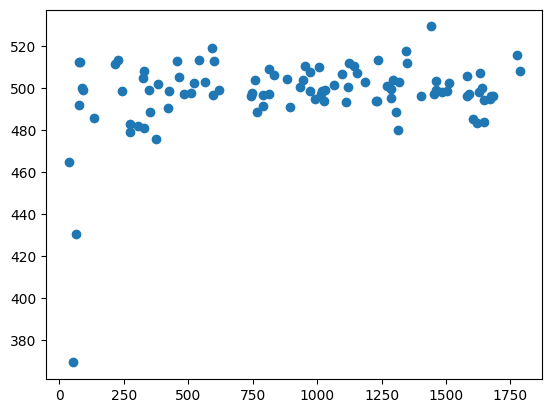

In [4]:
import matplotlib.pyplot as plt 
plt.scatter(data['t_test'], data['S_test'])
plt.show()

### Тестовые данные (непрерывные)

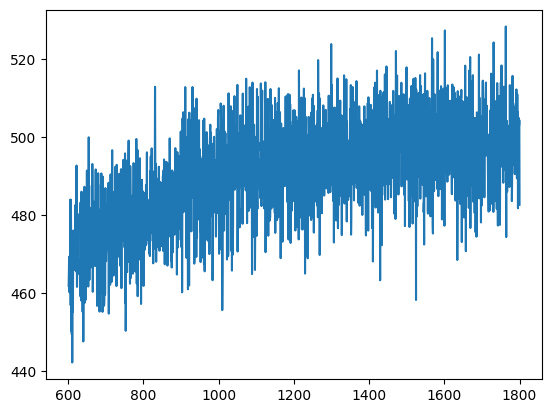

In [4]:
import matplotlib.pyplot as plt 
plt.plot(data['t_test'], data['S_test'])
plt.show()

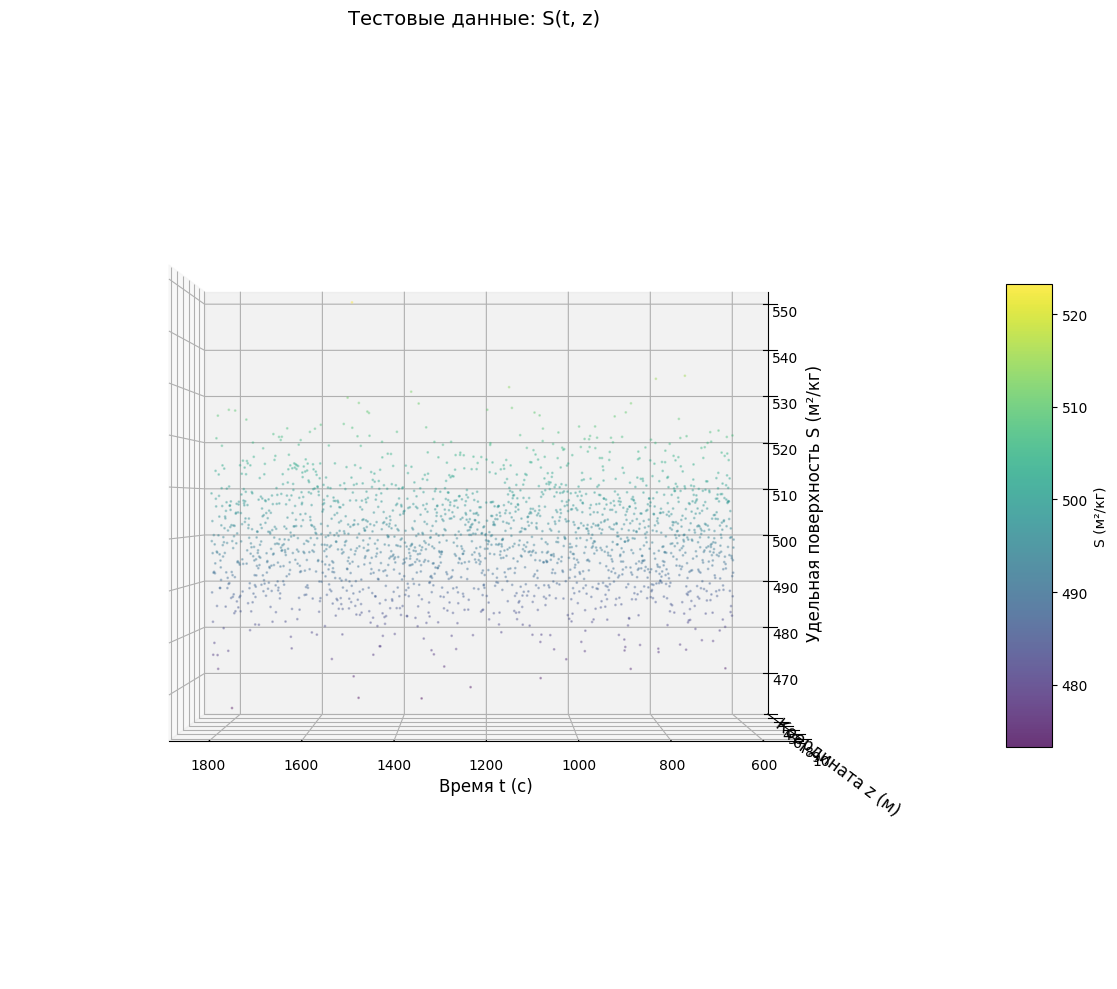

In [7]:
t_test = data['t_test'].detach().numpy().flatten()
z_test = data['z_test'].detach().numpy().flatten()
S_test = data['S_test'].detach().numpy().flatten()

# Создаем регулярную сетку для интерполяции
t_grid = np.linspace(t_test.min(), t_test.max(), 50)
z_grid = np.linspace(z_test.min(), z_test.max(), 50)
T, Z = np.meshgrid(t_grid, z_grid)

# Интерполируем данные на регулярную сетку
S_grid = griddata((t_test, z_test), S_test, (T, Z), method='cubic')

# Строим 3D поверхность
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Поверхность
surf = ax.plot_surface(T, Z, S_grid, cmap='viridis', alpha=0.8, 
                        linewidth=0, antialiased=True)

# Добавляем исходные точки
ax.scatter(t_test, z_test, S_test, c=S_test, cmap='viridis', 
            s=1, alpha=0.3, label='Данные')

# Настройка осей
ax.set_xlabel('Время t (с)', fontsize=12, labelpad=10)
ax.set_ylabel('Координата z (м)', fontsize=12, labelpad=10)
ax.set_zlabel('Удельная поверхность S (м²/кг)', fontsize=12, labelpad=10)
ax.set_title('Тестовые данные: S(t, z)', fontsize=14, pad=20)

# Colorbar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='S (м²/кг)')

plt.tight_layout()
ax.view_init(elev=0,  
            azim=90)
plt.show()

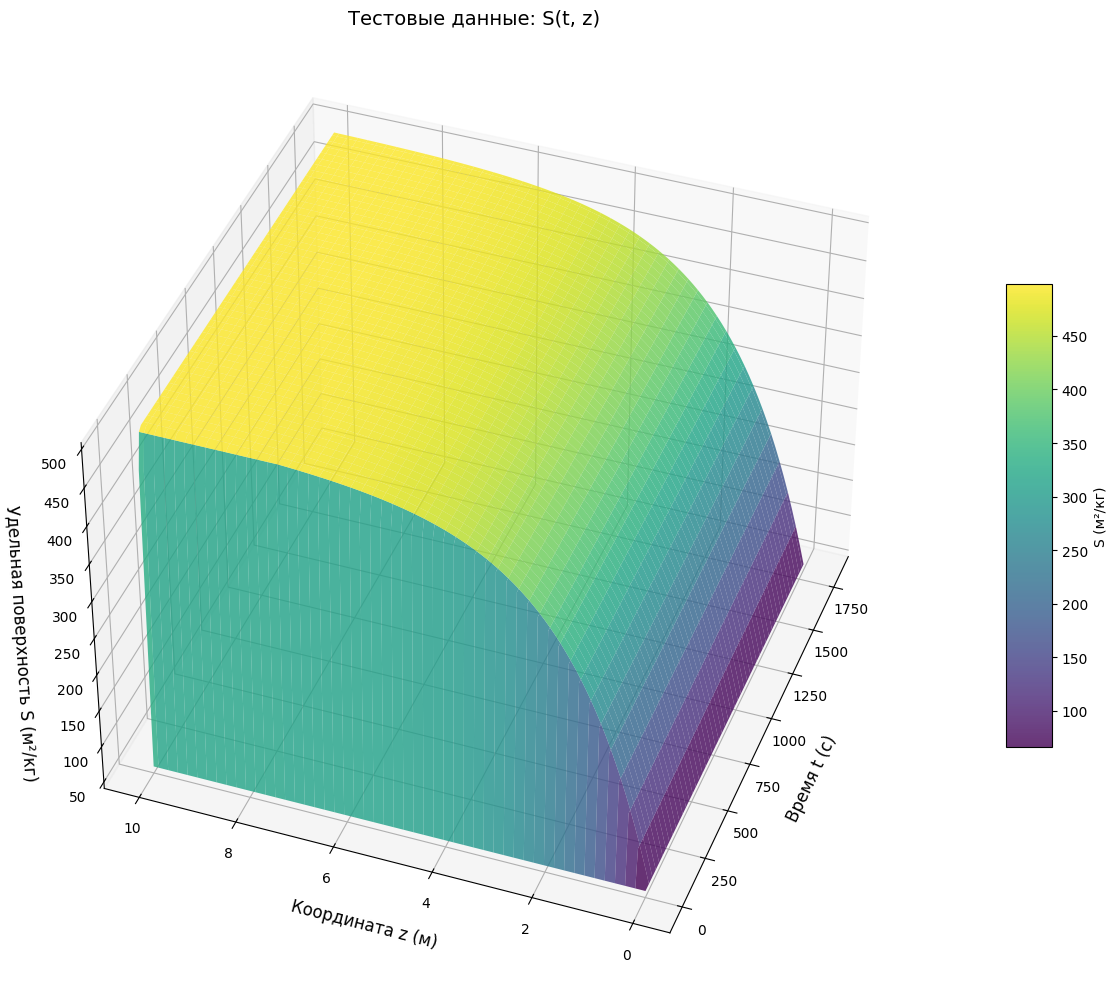

In [20]:
T, Z, S = data["T"].numpy(), data["Z"].numpy(), data["S"]

# Строим 3D поверхность
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Поверхность
surf = ax.plot_surface(T, Z, S, cmap='viridis', alpha=0.8, 
                        linewidth=0, antialiased=True)

# Добавляем исходные точки
# ax.scatter(t_test, z_test, S_test, c=S_test, cmap='viridis', 
#             s=1, alpha=0.3, label='Данные')

# Настройка осей
ax.set_xlabel('Время t (с)', fontsize=12, labelpad=10)
ax.set_ylabel('Координата z (м)', fontsize=12, labelpad=10)
ax.set_zlabel('Удельная поверхность S (м²/кг)', fontsize=12, labelpad=10)
ax.set_title('Тестовые данные: S(t, z)', fontsize=14, pad=20)

# Colorbar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='S (м²/кг)')

plt.tight_layout()
ax.view_init(elev=40,  # вращение в вертикальной плоскости
            azim=200) # вращение в горизантальной плоскости
plt.show()

# PINN

In [24]:
import os

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

from networks.PINN import PINN
from loss.pinn_loss import pinn_loss

## PINN, обученная с коэффициентами, которые мы задали

k = 0.12 <br>
v_m = 0.2 <br>
epochs = 30_000

### все параметры (включая mse)

 lambda_pde=3.,<br>
lambda_bc=1.,<br>
lambda_ic=1.,<br>
lambda_mse=2.<br>

In [9]:
pinn = PINN()

optimizer = optim.Adam(pinn.parameters(), lr=0.001)

history = []

print('НАЧАЛО ОБУЧЕНИЯ PINN')
for epoch in range(30_000):
    pinn.train()
    optimizer.zero_grad()

    loss = pinn_loss(pinn,
                    data["t_pde"], data["z_pde"],
                    data["t_bc"], data["z_bc"], data["S_bc"],
                    data["t_ic"], data["z_ic"], data["S_ic"],
                    t_real=data["t_train"], z_real=data["z_train"], S_real=data["S_train"],
                    lambda_pde=3.,
                    lambda_bc=1.,
                    lambda_ic=1.,
                    lambda_mse=2.,
    )

    loss.backward()
    optimizer.step()

    history.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.3f}")
        

НАЧАЛО ОБУЧЕНИЯ PINN
Epoch 0 | Loss: 512323.344
Epoch 100 | Loss: 480226.250
Epoch 200 | Loss: 458416.688
Epoch 300 | Loss: 438576.938
Epoch 400 | Loss: 420110.875
Epoch 500 | Loss: 402837.719
Epoch 600 | Loss: 386647.250
Epoch 700 | Loss: 370972.438
Epoch 800 | Loss: 355884.969
Epoch 900 | Loss: 341524.406
Epoch 1000 | Loss: 327854.312
Epoch 1100 | Loss: 314848.719
Epoch 1200 | Loss: 302480.750
Epoch 1300 | Loss: 290719.344
Epoch 1400 | Loss: 279542.625
Epoch 1500 | Loss: 268948.750
Epoch 1600 | Loss: 258916.969
Epoch 1700 | Loss: 249428.594
Epoch 1800 | Loss: 240464.203
Epoch 1900 | Loss: 231996.422
Epoch 2000 | Loss: 223991.766
Epoch 2100 | Loss: 216450.219
Epoch 2200 | Loss: 209361.578
Epoch 2300 | Loss: 202704.078
Epoch 2400 | Loss: 196472.969
Epoch 2500 | Loss: 190648.891
Epoch 2600 | Loss: 185222.938
Epoch 2700 | Loss: 180175.500
Epoch 2800 | Loss: 175494.031
Epoch 2900 | Loss: 171164.078
Epoch 3000 | Loss: 167161.750
Epoch 3100 | Loss: 144068.969
Epoch 3200 | Loss: 122115.383
E

In [10]:
torch.save({
    "model_state_dict": pinn.state_dict()
}, os.path.join('.', 'models', 'pinn_mse_pde.pth'))

### без MSE

lambda_pde=2.,<br>
lambda_bc=1.,<br>
lambda_ic=1.,<br>
lambda_mse=0.<br>

In [11]:
pinn = PINN()

optimizer = optim.Adam(pinn.parameters(), lr=0.001)

history = []

print('НАЧАЛО ОБУЧЕНИЯ PINN')
for epoch in range(30_000):
    pinn.train()
    optimizer.zero_grad()

    loss = pinn_loss(pinn,
                    data["t_pde"], data["z_pde"],
                    data["t_bc"], data["z_bc"], data["S_bc"],
                    data["t_ic"], data["z_ic"], data["S_ic"],
                    t_real=data["t_train"], z_real=data["z_train"], S_real=data["S_train"],
                    lambda_pde=2.,
                    lambda_bc=1.,
                    lambda_ic=1.,
                    lambda_mse=0.,
    )

    loss.backward()
    optimizer.step()

    history.append(loss.item())

    S_pred = pinn(data['t_train'], data['z_train'])
    diff = data["S_train"] - S_pred

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.3f} | diff: {torch.mean(diff**2)}")
        

НАЧАЛО ОБУЧЕНИЯ PINN
Epoch 0 | Loss: 12208.944 | diff: 248000.6875
Epoch 100 | Loss: 9204.741 | diff: 233293.65625
Epoch 200 | Loss: 7780.582 | diff: 224227.796875
Epoch 300 | Loss: 6893.516 | diff: 216883.484375
Epoch 400 | Loss: 6355.116 | diff: 210951.921875
Epoch 500 | Loss: 6047.575 | diff: 206282.953125
Epoch 600 | Loss: 5884.697 | diff: 202739.078125
Epoch 700 | Loss: 5805.472 | diff: 200160.921875
Epoch 800 | Loss: 5770.278 | diff: 198370.296875
Epoch 900 | Loss: 5755.989 | diff: 197184.875
Epoch 1000 | Loss: 5750.560 | diff: 196437.0
Epoch 1100 | Loss: 5747.776 | diff: 195982.921875
Epoch 1200 | Loss: 5700.937 | diff: 194956.234375
Epoch 1300 | Loss: 5683.094 | diff: 193542.59375
Epoch 1400 | Loss: 5674.049 | diff: 192460.90625
Epoch 1500 | Loss: 5668.344 | diff: 191652.875
Epoch 1600 | Loss: 5664.445 | diff: 191055.359375
Epoch 1700 | Loss: 5661.754 | diff: 190630.359375
Epoch 1800 | Loss: 5660.145 | diff: 190351.515625
Epoch 1900 | Loss: 5659.197 | diff: 190185.34375
Epoch 2

In [12]:
torch.save({
    "model_state_dict": pinn.state_dict()
}, os.path.join('.', 'models', 'pinn_pde.pth'))

### без pde

lambda_pde=0.,<br>
lambda_bc=1.,<br>
lambda_ic=1.,<br>
lambda_mse=2.<br>

In [15]:
pinn = PINN()

optimizer = optim.Adam(pinn.parameters(), lr=0.001)

history = []

print('НАЧАЛО ОБУЧЕНИЯ PINN')
for epoch in range(30_000):
    pinn.train()
    optimizer.zero_grad()

    loss = pinn_loss(pinn,
                    data["t_pde"], data["z_pde"],
                    data["t_bc"], data["z_bc"], data["S_bc"],
                    data["t_ic"], data["z_ic"], data["S_ic"],
                    t_real=data["t_train"], z_real=data["z_train"], S_real=data["S_train"],
                    lambda_pde=0.,
                    lambda_bc=1.,
                    lambda_ic=1.,
                    lambda_mse=2.,
    )

    loss.backward()
    optimizer.step()

    history.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.3f}")

НАЧАЛО ОБУЧЕНИЯ PINN
Epoch 0 | Loss: 502019.625
Epoch 100 | Loss: 469002.062
Epoch 200 | Loss: 448028.906
Epoch 300 | Loss: 428747.781
Epoch 400 | Loss: 410769.750
Epoch 500 | Loss: 393945.031
Epoch 600 | Loss: 378181.656
Epoch 700 | Loss: 363383.625
Epoch 800 | Loss: 348384.250
Epoch 900 | Loss: 334319.875
Epoch 1000 | Loss: 320931.375
Epoch 1100 | Loss: 308201.688
Epoch 1200 | Loss: 296105.750
Epoch 1300 | Loss: 284621.844
Epoch 1400 | Loss: 273729.156
Epoch 1500 | Loss: 263407.500
Epoch 1600 | Loss: 253637.031
Epoch 1700 | Loss: 244396.125
Epoch 1800 | Loss: 235669.828
Epoch 1900 | Loss: 227427.609
Epoch 2000 | Loss: 217934.781
Epoch 2100 | Loss: 201015.359
Epoch 2200 | Loss: 188850.938
Epoch 2300 | Loss: 177509.531
Epoch 2400 | Loss: 167230.516
Epoch 2500 | Loss: 163123.062
Epoch 2600 | Loss: 148728.234
Epoch 2700 | Loss: 139637.344
Epoch 2800 | Loss: 131213.828
Epoch 2900 | Loss: 123659.680
Epoch 3000 | Loss: 115587.242
Epoch 3100 | Loss: 151286.516
Epoch 3200 | Loss: 101744.609
E

In [16]:
torch.save({
    "model_state_dict": pinn.state_dict()
}, os.path.join('.', 'models', 'pinn_mse.pth'))

### Визуализация 3х моделей

In [25]:
# --- MSE PDE ---
pinn_mse_pde = PINN()

checkpoint = torch.load(os.path.join('.', 'models', "pinn_mse_pde.pth"))
pinn_mse_pde.load_state_dict(checkpoint["model_state_dict"])

pinn_mse_pde.eval()

# --- MSE ---
pinn_mse = PINN()

checkpoint = torch.load(os.path.join('.', 'models', "pinn_mse.pth"))
pinn_mse.load_state_dict(checkpoint["model_state_dict"])

pinn_mse.eval()

# --- PDE ---
pinn_pde = PINN()

checkpoint = torch.load(os.path.join('.', 'models', "pinn_pde.pth"))
pinn_pde.load_state_dict(checkpoint["model_state_dict"])

pinn_pde.eval()

PINN(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=100, bias=True)
    (1): Tanh()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): Tanh()
    (4): Linear(in_features=100, out_features=1, bias=True)
  )
)

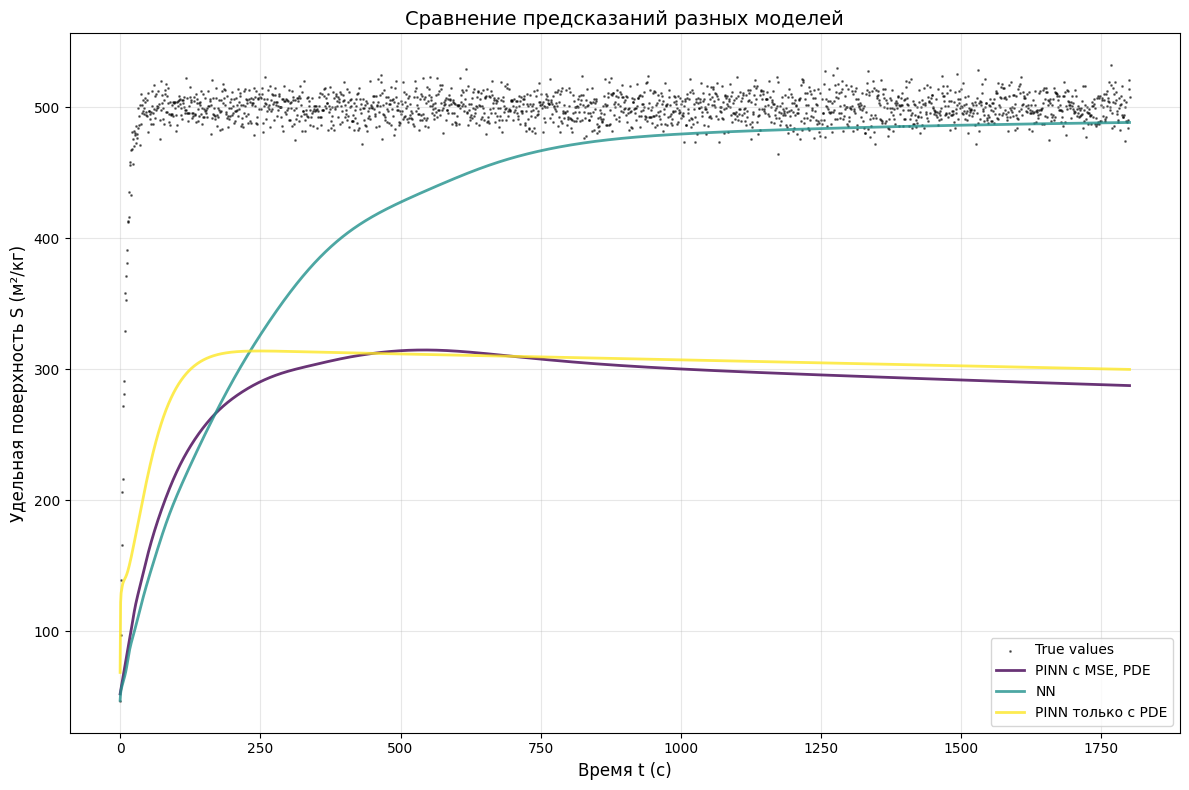

In [ ]:
# неактуальный график
plt.figure(figsize=(12, 8))
t_test = data['t_train'].detach().numpy().flatten()
z_test = data['z_train'].detach().numpy().flatten()
S_test = data['S_train'].detach().numpy().flatten()
models = [pinn_mse_pde, pinn_mse, pinn_pde]
model_names = ['PINN с MSE, PDE', 'NN', 'PINN только с PDE']

# Строим истинные значения
plt.scatter(t_test, S_test, s=1, alpha=0.5, 
               color='black', label='True values')
    
# Строим предсказания каждой модели
colors = plt.cm.viridis(np.linspace(0, 1, len(models)))

for i, (model, name) in enumerate(zip(models, model_names)):
    S_pred = model(data['t_train'], data['z_train']).detach().numpy().flatten()
    plt.plot(t_test, S_pred, linewidth=2, 
                color=colors[i], label=name, alpha=0.8)

plt.xlabel('Время t (с)', fontsize=12)
plt.ylabel('Удельная поверхность S (м²/кг)', fontsize=12)
plt.title('Сравнение предсказаний разных моделей', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [61]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.lines import Line2D

def plot_multiple_pinns(models_dict, t_max=1800.0, z_max=10.0, v_m=0.2, k=0.12, S_max=500.0, S0=50.0):
    """
    Строит сравнительные графики для нескольких моделей.
    
    Аргументы:
        models_dict (dict): Словарь вида {'Имя модели 1': model1, 'Имя модели 2': model2}
    """
    # 1. Создаем равномерную сетку
    n_points = 100
    t_lin = np.linspace(0, t_max, n_points)
    z_lin = np.linspace(0, z_max, n_points)
    T, Z = np.meshgrid(t_lin, z_lin, indexing='ij')

    # 2. Вычисляем точное аналитическое решение
    tau = T - Z / v_m
    S_exact = np.where(
        tau > 0,
        S_max - (S_max - S0) * np.exp(-k * Z / v_m),
        S_max - (S_max - S0) * np.exp(-k * T)
    )
    # S_exact = data['S_test']

    # 3. Подготовка тензоров для моделей
    T_tensor = torch.tensor(T, dtype=torch.float32).flatten().unsqueeze(1)
    Z_tensor = torch.tensor(Z, dtype=torch.float32).flatten().unsqueeze(1)

    # 4. Собираем предсказания всех моделей
    predictions = {}
    for name, model in models_dict.items():
        S_pred_tensor = model.predict(T_tensor, Z_tensor)
        predictions[name] = S_pred_tensor.numpy().reshape(T.shape)

    # Палитра контрастных цветов для разных моделей
    colors = ['crimson', 'forestgreen', 'darkorange', 'purple', 'teal']
    
    # ==========================================
    # ПОСТРОЕНИЕ ГРАФИКОВ
    # ==========================================
    
    # --- График 1: 3D Сравнение ---
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Поверхность аналитики (полупрозрачная синяя)
    ax.plot_surface(T, Z, S_exact, alpha=0.3, color='royalblue')
    
    # Подготавливаем элементы для легенды 3D графика
    custom_lines = [Line2D([0], [0], color='royalblue', lw=6, alpha=0.4)]
    legend_labels = ['Аналитическое решение']

    # Наносим сетки предсказаний для каждой модели
    for i, (name, S_pred) in enumerate(predictions.items()):
        color = colors[i % len(colors)]
        # rstride/cstride задают густоту сетки. 
        ax.plot_wireframe(T, Z, S_pred, color=color, alpha=0.7, rstride=5, cstride=5)
        custom_lines.append(Line2D([0], [0], color=color, lw=2))
        legend_labels.append(name)
    
    ax.set_xlabel('Время t, с')
    ax.set_ylabel('Координата z, м')
    ax.set_zlabel('Удельная поверхность S, м2/кг')
    ax.set_zlim(bottom=0)
    ax.set_title('Сравнение нескольких PINN моделей (3D)')
    ax.legend(custom_lines, legend_labels, loc='upper left')
    plt.tight_layout()
    plt.show()

    # --- Графики 2 и 3: Плоские срезы (2D) ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Срез A: По координате Z в фиксированный момент времени T
    t_idx = n_points // 2 # Середина процесса (t = 900 с)
    current_t = t_lin[t_idx]
    
    # Рисуем аналитику жирной полупрозрачной линией
    axes[0].plot(z_lin, S_exact[t_idx, :], color='royalblue', linewidth=4, alpha=0.4, label='Аналитика')
    
    # Наносим предсказания моделей пунктиром
    for i, (name, S_pred) in enumerate(predictions.items()):
        color = colors[i % len(colors)]
        axes[0].plot(z_lin, S_pred[t_idx, :], color=color, linestyle='--', linewidth=2.5, label=name)
        
    axes[0].set_xlabel('Координата в мельнице z, м')
    axes[0].set_ylabel('Удельная поверхность S, м2/кг')
    axes[0].set_title(f'Профиль S(z) в момент времени t = {current_t:.0f} с')
    axes[0].grid(True, linestyle=':', alpha=0.7)
    axes[0].legend()

    # Срез B: Во времени T в фиксированной координате Z (на выходе)
    z_idx = -1 # Конец мельницы (z = 10 м)
    current_z = z_lin[z_idx]
    
    axes[1].plot(t_lin, S_exact[:, z_idx], color='royalblue', linewidth=4, alpha=0.4, label='Аналитика')
    
    for i, (name, S_pred) in enumerate(predictions.items()):
        color = colors[i % len(colors)]
        axes[1].plot(t_lin, S_pred[:, z_idx], color=color, linestyle='--', linewidth=2.5, label=name)
        
    axes[1].set_xlabel('Время t, с')
    axes[1].set_ylabel('Удельная поверхность S, м2/кг')
    axes[1].set_title(f'Динамика S(t) на выходе из мельницы (z = {current_z:.1f} м)')
    axes[1].grid(True, linestyle=':', alpha=0.7)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

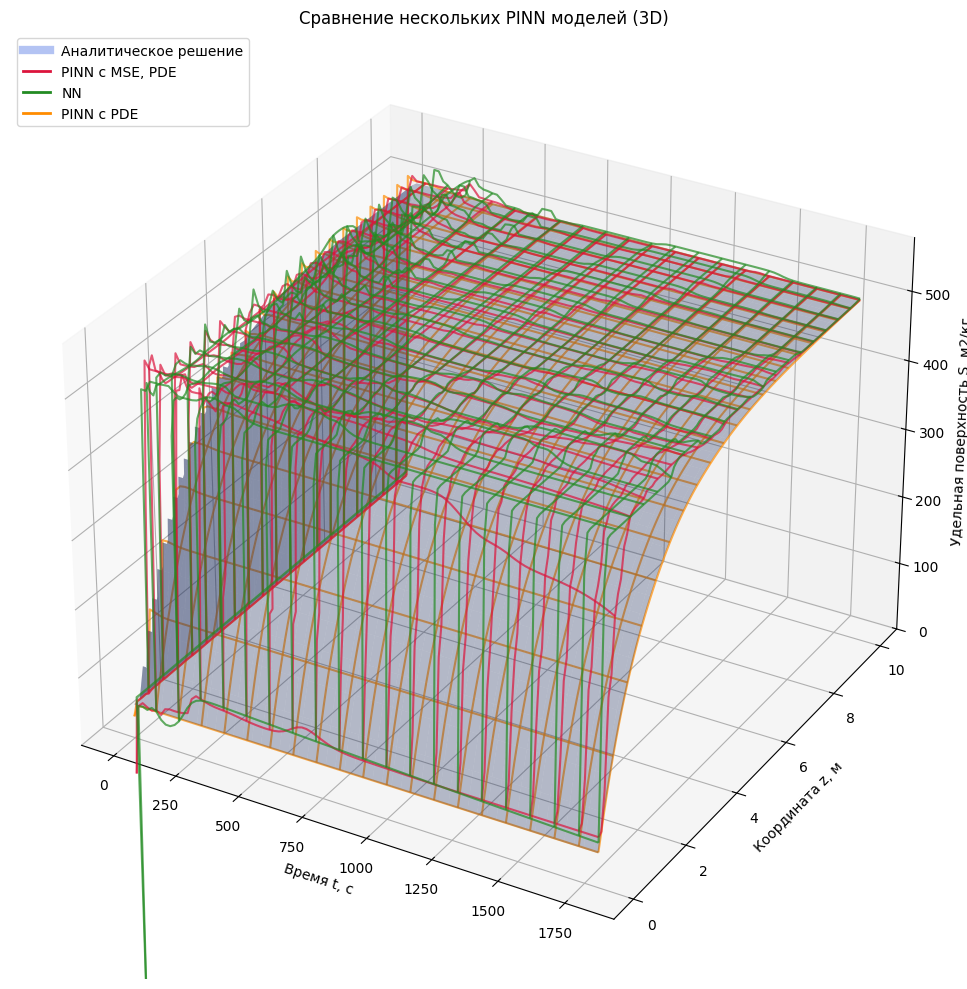

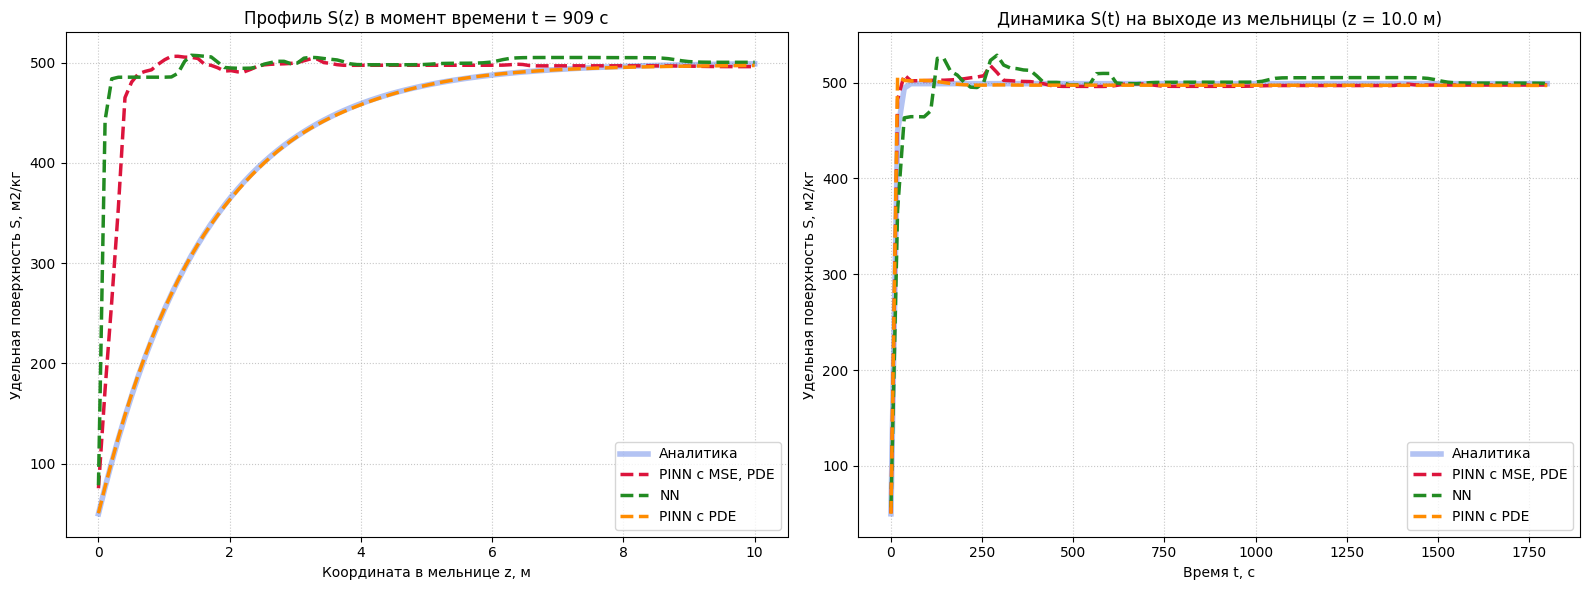

In [62]:
my_models = {
    "PINN с MSE, PDE": pinn_mse_pde,
    "NN": pinn_mse,
    "PINN с PDE": pinn_pde
}

# Строим графики
plot_multiple_pinns(my_models)

## PINN с MSE и обучаемыми параметрами

Обучение PINN с MSE и обучаемым параметром k

In [10]:
pinn = PINN()

optimizer = optim.Adam(pinn.parameters(), lr=0.001)

history = []
parametr_k = []

print('НАЧАЛО ОБУЧЕНИЯ PINN')
for epoch in range(30_000):
    pinn.train()
    optimizer.zero_grad()

    loss = pinn_loss(pinn,
        data["t_train"], data["z_train"],
        data["t_bc"], data["z_bc"], data["S_bc"],
        data["t_ic"], data["z_ic"], data["S_ic"],
        t_real=data["t_train"], z_real=data["z_train"], S_real=data["S_train"],
        lambda_pde=1.,
        lambda_bc=1.,
        lambda_ic=1.,
        lambda_mse=1000.,
    )

    loss.backward()
    optimizer.step()

    history.append(loss.item())
    parametr_k.append(pinn.k.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.3f} | k: {pinn.k.item():.3f}")
        

НАЧАЛО ОБУЧЕНИЯ PINN
Epoch 0 | Loss: 157385504.000 | k: 0.999
Epoch 100 | Loss: 149573840.000 | k: 0.902
Epoch 200 | Loss: 142293504.000 | k: 0.811
Epoch 300 | Loss: 135312896.000 | k: 0.727
Epoch 400 | Loss: 128621528.000 | k: 0.649
Epoch 500 | Loss: 122208536.000 | k: 0.578
Epoch 600 | Loss: 116063632.000 | k: 0.513
Epoch 700 | Loss: 110177048.000 | k: 0.454
Epoch 800 | Loss: 104539488.000 | k: 0.400
Epoch 900 | Loss: 99141816.000 | k: 0.352
Epoch 1000 | Loss: 93974008.000 | k: 0.308
Epoch 1100 | Loss: 89018144.000 | k: 0.270
Epoch 1200 | Loss: 84268480.000 | k: 0.235
Epoch 1300 | Loss: 79719960.000 | k: 0.204
Epoch 1400 | Loss: 75366136.000 | k: 0.177
Epoch 1500 | Loss: 71199632.000 | k: 0.153
Epoch 1600 | Loss: 67214176.000 | k: 0.132
Epoch 1700 | Loss: 63403480.000 | k: 0.114
Epoch 1800 | Loss: 59761532.000 | k: 0.098
Epoch 1900 | Loss: 56282564.000 | k: 0.084
Epoch 2000 | Loss: 52961092.000 | k: 0.073
Epoch 2100 | Loss: 49791840.000 | k: 0.063
Epoch 2200 | Loss: 46769752.000 | k:

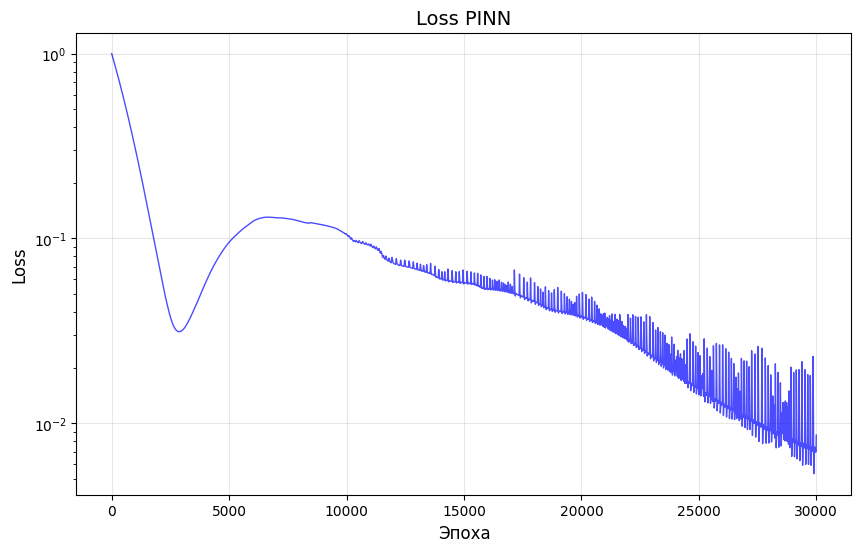

In [11]:
import matplotlib.pyplot as plt

def plot_loss(history):
    """
    Построение графика функции потерь
    """
    plt.figure(figsize=(10, 6))
    plt.plot(history, linewidth=1, color='blue', alpha=0.7)
    plt.xlabel('Эпоха', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Loss PINN', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.yscale('log') 
    # plt.tight_layout()
    plt.show()

# Вызов после обучения
plot_loss(parametr_k)

# MDN

In [ ]:
import math

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

from networks.MDN import MDN
from loss.mdn_loss import mdn_loss

In [6]:
pinn = PINN()

checkpoint = torch.load(os.path.join('.', 'models', "pinn.pth"))
pinn.load_state_dict(checkpoint["model_state_dict"])

# pinn.v_m.data = checkpoint["v_m"]
# pinn.k.data = checkpoint["k"]

pinn.eval()

PINN(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=100, bias=True)
    (1): Tanh()
    (2): Linear(in_features=100, out_features=1, bias=True)
  )
)

In [96]:
def mdn_loss(pi, mu, sigma, target):
    target = target.expand_as(mu)

    # Gaussian PDF
    coeff = 1.0 / (sigma * torch.sqrt(torch.tensor(2.0 * torch.pi)))
    exponent = torch.exp(-0.5 * ((target - mu) / sigma)**2)

    probs = coeff * exponent
    weighted = pi * probs

    # weighted имеет форму (batch_size, n_components)
    sum_over_components = torch.sum(weighted, dim=1)  # форма (batch_size,)
    print(sum_over_components.shape)



    # loss = -torch.log(sum_over_components + 1e-8)      # форма (batch_size,)
    

    loss = -torch.log(torch.sum(weighted) + 1e-6)
    loss = torch.mean(loss)           # скаляр
    
    return loss

In [14]:
def mdn_loss(pi, mu, sigma, target):
    target = target.expand_as(mu)

    log_probs = -0.5 * ((target - mu) / sigma)**2 \
                - torch.log(sigma) \
                - 0.5 * math.log(2 * math.pi)

    log_weighted = torch.log(pi) + log_probs
    # print(log_weighted)

    loss = -torch.logsumexp(log_weighted, dim=1)
    return loss.mean()

In [16]:
mdn = MDN()

optimizer = optim.Adam(mdn.parameters(), lr=0.001)

history = []

print('НАЧАЛО ОБУЧЕНИЯ MDN')
for epoch in range(30000):
    mdn.train()
    optimizer.zero_grad()

    pi, mu, sigma = mdn.forward(S_pred)

    loss = mdn_loss(pi, mu, sigma, data['S_train'])

    
    loss.backward()
    optimizer.step()

    history.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.6f}")

НАЧАЛО ОБУЧЕНИЯ MDN
Epoch 0 | Loss: 126362.007812
Epoch 100 | Loss: 2331.195557
Epoch 200 | Loss: 1534.125732
Epoch 300 | Loss: 1152.785156
Epoch 400 | Loss: 928.347900
Epoch 500 | Loss: 779.304688
Epoch 600 | Loss: 672.390686
Epoch 700 | Loss: 591.509949
Epoch 800 | Loss: 527.907715
Epoch 900 | Loss: 476.399139
Epoch 1000 | Loss: 433.711487
Epoch 1100 | Loss: 397.670898
Epoch 1200 | Loss: 366.774261
Epoch 1300 | Loss: 339.947815
Epoch 1400 | Loss: 316.401825
Epoch 1500 | Loss: 295.542908
Epoch 1600 | Loss: 276.914612
Epoch 1700 | Loss: 260.161499
Epoch 1800 | Loss: 245.001053
Epoch 1900 | Loss: 231.205948
Epoch 2000 | Loss: 218.591797
Epoch 2100 | Loss: 207.006592
Epoch 2200 | Loss: 196.323990
Epoch 2300 | Loss: 186.438248
Epoch 2400 | Loss: 177.260193
Epoch 2500 | Loss: 168.713791
Epoch 2600 | Loss: 160.734100
Epoch 2700 | Loss: 153.264999
Epoch 2800 | Loss: 146.257935
Epoch 2900 | Loss: 139.670624
Epoch 3000 | Loss: 133.465942
Epoch 3100 | Loss: 127.611481
Epoch 3200 | Loss: 122.078

In [29]:
torch.save({
    "model_state_dict": mdn.state_dict()
}, os.path.join('.', 'models', 'mdn.pth'))

In [13]:
mdn = MDN()

checkpoint = torch.load(os.path.join('.', 'models', "mdn.pth"))
mdn.load_state_dict(checkpoint["model_state_dict"])

# pinn.v_m.data = checkpoint["v_m"]
# pinn.k.data = checkpoint["k"]

mdn.eval()

MDN(
  (layers): Sequential(
    (0): Linear(in_features=1, out_features=100, bias=True)
    (1): Tanh()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): Tanh()
  )
  (pi): Linear(in_features=100, out_features=3, bias=True)
  (mu): Linear(in_features=100, out_features=3, bias=True)
  (sigma): Linear(in_features=100, out_features=3, bias=True)
)

In [17]:
mdn.predict(S_pred)

(tensor([378.8259, 378.8259, 378.8259,  ..., 378.8259, 378.8259, 378.8259]),
 tensor([151.4041, 151.4041, 151.4041,  ..., 151.4041, 151.4041, 151.4041]),
 tensor([606.2477, 606.2477, 606.2477,  ..., 606.2477, 606.2477, 606.2477]))

In [18]:
mean, lower, upper = mdn.predict(S_pred)

# График

In [19]:
import torch
import matplotlib.pyplot as plt

@torch.no_grad()
def plot_mdn_results(model, x, y_true, pinn_pred, title):
    model.eval()

    # сортировка для красивой линии
    x_sorted, indices = torch.sort(x.squeeze())
    y_true_sorted = y_true.squeeze()[indices]

    # MDN предсказания
    mean, lower, upper = model.predict(x)

    mean = mean[indices]
    lower = lower[indices]
    upper = upper[indices]

    # === plotting ===
    plt.figure(figsize=(8, 5))

    # реальные данные
    plt.scatter(x_sorted.cpu(), y_true_sorted.cpu(),
                s=10, alpha=0.5, label="Data")

    # PINN (если есть)
    if pinn_pred is not None:
        pinn_pred = pinn_pred.squeeze()[indices]
        plt.plot(x_sorted.cpu(), pinn_pred.cpu(),
                 linestyle="--", label="PINN")

    # MDN mean
    plt.plot(x_sorted.cpu(), mean.cpu(),
             linewidth=2, label="MDN mean")

    # uncertainty band
    plt.fill_between(
        x_sorted.cpu().numpy(),
        lower.cpu().numpy(),
        upper.cpu().numpy(),
        alpha=0.3,
        label="MDN ±1.96σ"
    )
    
    plt.xlabel(title)
    plt.ylabel("S")
    plt.legend()
    plt.title("MDN uncertainty visualization")

    plt.tight_layout()
    plt.show()

In [20]:
plot_mdn_results(
    model=mdn,
    x=data['t_train'],
    y_true=data['S_train'],
    pinn_pred=S_pred,
    title='t'
)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x2000 and 1x100)

In [20]:
plot_mdn_results(
    model=mdn,
    x=data['z_train'],
    y_true=data['S_train'],
    pinn_pred=S_pred,
    title='z'
)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x1000 and 1x100)